In [1]:

import numpy as np

np.random.seed(2026)

# ---- 参数设置 ----
n_samples = 500       # 样本数
n_genes = 100         # 基因总数
modules = {
    "prolif": 20,     # 增殖模块
    "immune": 20,     # 免疫模块
    "metab": 20,      # 代谢模块
    "emt": 20,        # EMT模块
    "house": 20       # 管家模块
}
assert sum(modules.values()) == n_genes

# 相关性（同模块内的相关系数）
rho_by_module = {
    "prolif": 0.6,
    "immune": 0.5,
    "metab": 0.4,
    "emt": 0.5,
    "house": 0.1
}

# ---- 构造块相关协方差矩阵并采样 ----
X_blocks = []
labels = []
for name, p in modules.items():
    rho = rho_by_module[name]
    # 协方差矩阵：对角为1，非对角为rho
    cov = (1 - rho) * np.eye(p) + rho * np.ones((p, p))
    # 多元正态采样（均值0）
    block = np.random.multivariate_normal(mean=np.zeros(p), cov=cov, size=n_samples)
    X_blocks.append(block)
    labels += [name] * p

X = np.hstack(X_blocks)  # (N, 100)

# ---- 混杂：批次效应与年龄 ----
# 批次：A/B 两批，各占一半；给某些模块加偏移
batch = np.zeros((n_samples, 1))
batch[int(n_samples/2):] = 1  # 后半为批次B
# 给批次B在代谢模块上加偏移，在免疫模块上减偏移（模拟平台差异）
metab_idx = np.where(np.array(labels) == "metab")[0]
immune_idx = np.where(np.array(labels) == "immune")[0]
X[:, metab_idx] += batch * 0.5
X[:, immune_idx] -= batch * 0.3

# 年龄：正态分布，影响连续/分类表型
age = np.random.normal(60, 10, size=(n_samples, 1))  # 均值60，方差10

# ---- 标准化（基因表达按列标准化） ----
X_mean = X.mean(axis=0)
X_std = X.std(axis=0, ddof=1)
X_scaled = (X - X_mean) / (X_std + 1e-8)

# ---- 生物学设定的权重 ----
# 连续表型：IC50/增殖速度 ~ +prolif +metab -immune + age/批次 + 噪声
w_prolif = 2.0
w_metab  = 1.5
w_immune = -2.5
# 分类表型：恶性/转移 ~ +emt +prolif -immune + age/批次
w_emt    = 2.0
w_prolif_cls = 1.0
w_immune_cls = -1.5

# 将模块权重分配至各基因（同模块内随机扰动）
def module_weight(vec_idx, base_w):
    # 每个基因围绕base权重做小扰动，制造稀疏/不均匀
    w = base_w + np.random.normal(0, 0.3, size=len(vec_idx))
    # 稀疏化：只让其中约30%真正起作用
    mask = (np.random.rand(len(vec_idx)) < 0.3).astype(float)
    return w * mask

w_reg = np.zeros(n_genes)
w_reg[ np.where(np.array(labels)=="prolif")[0] ] += module_weight(np.where(np.array(labels)=="prolif")[0], w_prolif)
w_reg[ np.where(np.array(labels)=="metab")[0]  ] += module_weight(np.where(np.array(labels)=="metab")[0],  w_metab)
w_reg[ np.where(np.array(labels)=="immune")[0] ] += module_weight(np.where(np.array(labels)=="immune")[0], w_immune)

# 连续表型（加协变量与噪声）
noise = np.random.normal(0, 2.0, size=(n_samples,))
y_reg = X_scaled.dot(w_reg) + 0.02 * age[:,0] + 0.5 * batch[:,0] + noise
y_reg = y_reg.reshape(-1, 1)

# 分类表型 logits
w_cls = np.zeros(n_genes)
w_cls[ np.where(np.array(labels)=="emt")[0] ]    += module_weight(np.where(np.array(labels)=="emt")[0],    w_emt)
w_cls[ np.where(np.array(labels)=="prolif")[0] ] += module_weight(np.where(np.array(labels)=="prolif")[0], w_prolif_cls)
w_cls[ np.where(np.array(labels)=="immune")[0] ] += module_weight(np.where(np.array(labels)=="immune")[0], w_immune_cls)

logits = X_scaled.dot(w_cls) + 0.01 * age[:,0] + 0.3 * batch[:,0]
prob = 1 / (1 + np.exp(-logits))
y_clf = (prob > 0.5).astype(int).reshape(-1, 1)

# ---- 设计矩阵（含截距与不希望被正则的协变量列） ----
# 约定：前3列为 [intercept, batch, age]，其余为基因表达
X_design = np.hstack([np.ones((n_samples,1)), batch, age, X_scaled])

print("X_design:", X_design.shape)  # (N, 3+100)
print("y_reg:", y_reg.shape)
print("y_clf:", y_clf.shape)


X_design: (500, 103)
y_reg: (500, 1)
y_clf: (500, 1)


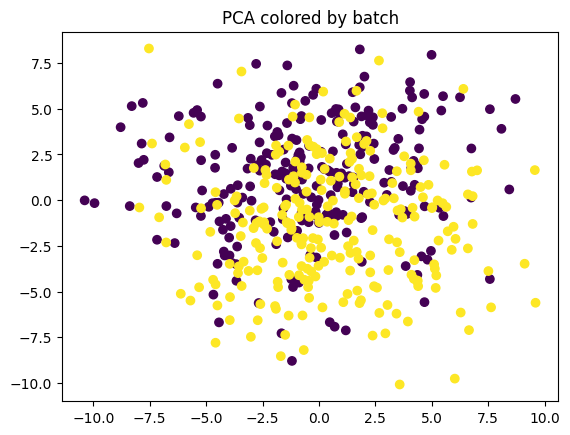

R2: 0.98880441686144
MSE: 2.9949754474694528


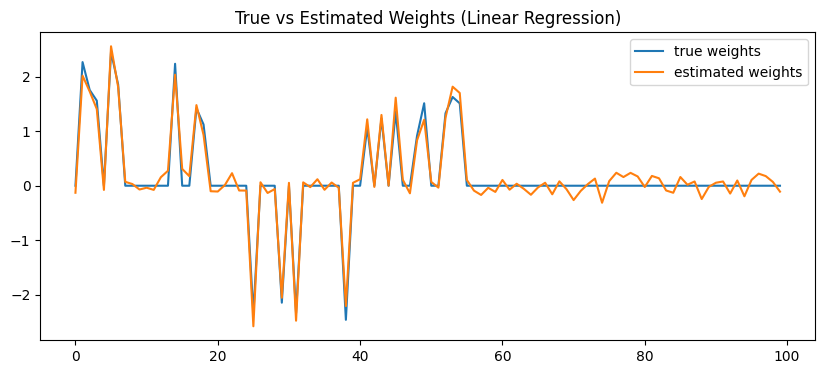

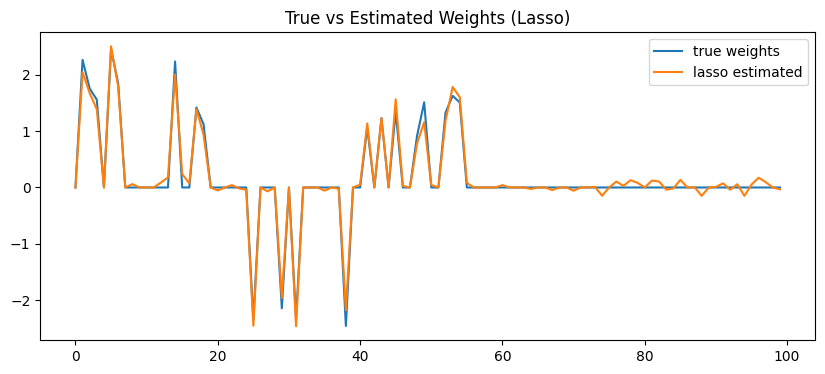

R2: 0.9800263201520709
MSE: 5.343239382871234
R2: 0.934023517773996
MSE: 17.649633961157168


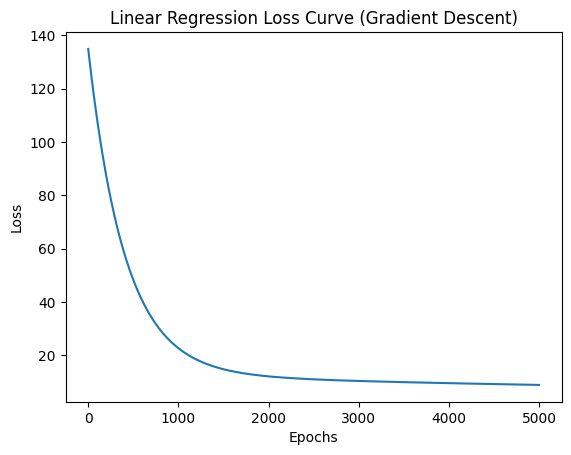

R2: 0.9330578046881454
MSE: 17.90797575055987


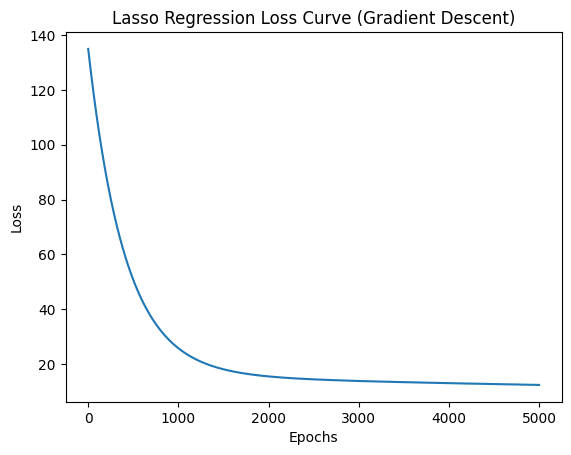

Accuracy: 0.934


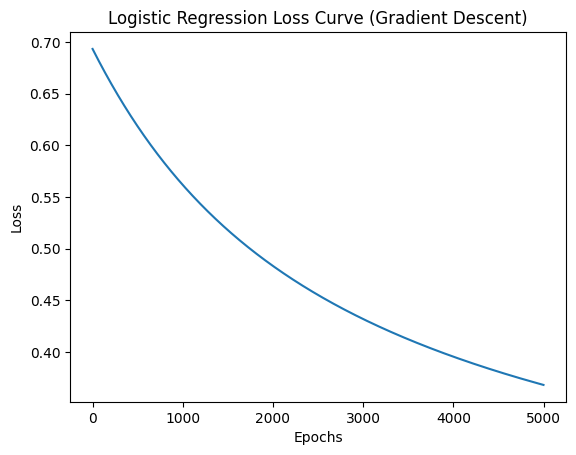

Accuracy: 0.934


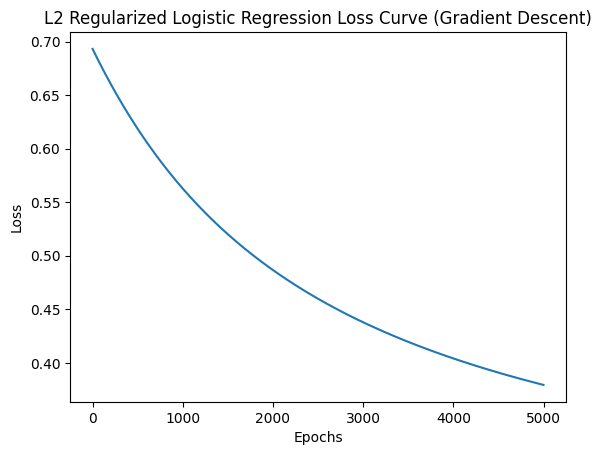

Accuracy: 0.882


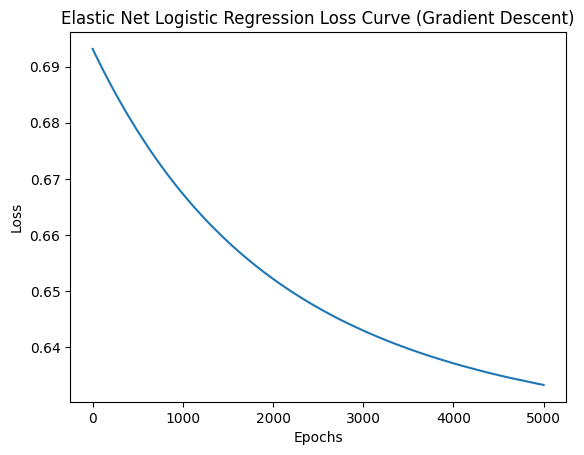

In [2]:
import numpy as np

np.random.seed(2026)

# ---- 参数设置 ----
n_samples = 500
n_genes = 100
modules = {
    "prolif": 20,
    "immune": 20,
    "metab": 20,
    "emt": 20,
    "house": 20
}


assert sum(modules.values()) == n_genes


# 相关性（同模块内的相关系数）
rho_by_module = {
    "prolif": 0.6,
    "immune": 0.5,
    "metab": 0.4,
    "emt": 0.5,
    "house": 0.1
}

# ---- 构造块相关协方差矩阵并采样 ----
X_blocks = []                                            # 每个模块的基因表达块
labels = []                                              # 基因标签列表
for name, p in modules.items():                          # 模块名与基因数
    rho = rho_by_module[name]                            # 相关系数
    
    # 协方差矩阵：对角为1，非对角为rho
    cov = (1 - rho) * np.eye(p) + rho * np.ones((p, p))  # 协方差矩阵
    
    # 多元正态采样（均值0）
    block = np.random.multivariate_normal(mean=np.zeros(p), cov=cov, size=n_samples)  # 采样
    X_blocks.append(block)                                                            # 添加到块列表
    labels += [name] * p                                                              # 基因标签列表扩展

X = np.hstack(X_blocks)
X.shape


batch = np.zeros((n_samples, 1))                     # 批次向量初始化，前 250 个样本属于 批次 A（batch = 0）
batch[int(n_samples/2):] = 1                         # 后半为批次B， batch = 1

metab_idx = np.where(np.array(labels) == "metab")[0]      # 代谢模块基因索引
immune_idx = np.where(np.array(labels) == "immune")[0]    # 免疫模块基因索引

X[:, metab_idx] += batch * 0.5
X[:, immune_idx] -= batch * 0.3

age = np.random.normal(60, 10, size=(n_samples, 1))

X_mean = X.mean(axis=0)
X_std = X.std(axis=0, ddof=1)
X_scaled = (X - X_mean) / (X_std + 1e-8)


# ---- 将模块权重分配至各基因（同模块内随机扰动） ----
#第一步：定义模块权重分配函数
def module_weight(vec_idx, base_w):
    # 每个基因围绕 base_w 做小扰动
    w = base_w + np.random.normal(0, 0.3, size=len(vec_idx))
    # 稀疏化：只让其中约30%真正起作用
    mask = (np.random.rand(len(vec_idx)) < 0.3).astype(float)
    return w * mask

# 第二步：构造连续表型的权重向量 w_reg
w_reg = np.zeros(n_genes)

# 增殖模块
w_reg[np.where(np.array(labels)=="prolif")[0]] += module_weight(
    np.where(np.array(labels)=="prolif")[0], base_w=2.0)

# 代谢模块
w_reg[np.where(np.array(labels)=="metab")[0]] += module_weight(
    np.where(np.array(labels)=="metab")[0], base_w=1.5)

# 免疫模块
w_reg[np.where(np.array(labels)=="immune")[0]] += module_weight(
    np.where(np.array(labels)=="immune")[0], base_w=-2.5)


# 第三步：构造分类表型的权重向量 w_cls
w_cls = np.zeros(n_genes)

# EMT模块
w_cls[np.where(np.array(labels)=="emt")[0]] += module_weight(
    np.where(np.array(labels)=="emt")[0], base_w=2.0)

# 增殖模块
w_cls[np.where(np.array(labels)=="prolif")[0]] += module_weight(
    np.where(np.array(labels)=="prolif")[0], base_w=1.0)

# 免疫模块
w_cls[np.where(np.array(labels)=="immune")[0]] += module_weight(
    np.where(np.array(labels)=="immune")[0], base_w=-1.5)

# 第四步：生成表型
# 连续表型（回归）
noise = np.random.normal(0, 2.0, size=(n_samples,))
y_reg = X_scaled.dot(w_reg) + 0.02 * age[:,0] + 0.5 * batch[:,0] + noise
y_reg = y_reg.reshape(-1, 1)

# 分类表型（逻辑回归）
logits = X_scaled.dot(w_cls) + 0.01 * age[:,0] + 0.3 * batch[:,0]
prob = 1 / (1 + np.exp(-logits))
y_clf = (prob > 0.5).astype(int).reshape(-1, 1)





from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=batch[:,0])
plt.title("PCA colored by batch")
plt.show()

# 线性回归评估
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(X_scaled, y_reg)

y_pred = lr.predict(X_scaled)

print("R2:", r2_score(y_reg, y_pred))
print("MSE:", mean_squared_error(y_reg, y_pred))

# 绘制真实权重与估计权重对比
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(w_reg, label="true weights")
plt.plot(lr.coef_.flatten(), label="estimated weights")
plt.legend()
plt.title("True vs Estimated Weights (Linear Regression)")
plt.show()

# lasso回归评估
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.05)
lasso.fit(X_scaled, y_reg)

plt.figure(figsize=(10,4))
plt.plot(w_reg, label="true weights")
plt.plot(lasso.coef_, label="lasso estimated")
plt.legend()
plt.title("True vs Estimated Weights (Lasso)")
plt.show()


# # 正规方程求线性回归
# # X_scaled: (n_samples, n_genes)
# # y_reg:    (n_samples, 1)

# # 计算 (X^T X)
# XtX = X_scaled.T.dot(X_scaled)

# # 计算 (X^T y)
# Xty = X_scaled.T.dot(y_reg)

# # 求解 w
# w_hat = np.linalg.inv(XtX).dot(Xty)

# # 预测
# y_pred = X_scaled.dot(w_hat)

# 1. 求解 w
XtX = X_scaled.T.dot(X_scaled)
Xty = X_scaled.T.dot(y_reg)
w_hat = np.linalg.inv(XtX).dot(Xty)

# 2. 预测
y_pred = X_scaled.dot(w_hat)

# 3. R2
ss_res = np.sum((y_reg - y_pred)**2)
ss_tot = np.sum((y_reg - np.mean(y_reg))**2)
R2 = 1 - ss_res / ss_tot

# 4. MSE
MSE = np.mean((y_reg - y_pred)**2)

print("R2:", R2)
print("MSE:", MSE)



# 梯度下降解法
m, n = X_scaled.shape
theta = np.zeros((n,1))
lr = 1e-4
epochs = 5000
losses = []
for epoch in range(epochs):
    y_hat = X_scaled @ theta
    error = y_hat - y_reg
    loss = (1/(2*m)) * np.sum(error**2)
    losses.append(loss)
    grad = (1/m) * (X_scaled.T @ error)
    theta -= lr * grad
print("R2:", 1 - np.sum((y_reg - X_scaled @ theta)**2) / np.sum((y_reg - np.mean(y_reg))**2))
print("MSE:", np.mean((y_reg - X_scaled @ theta)**2))

# 绘制损失曲线
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Linear Regression Loss Curve (Gradient Descent)")
plt.show()



# 梯度下降求lasso回归
m, n = X_scaled.shape
theta = np.zeros((n,1))
lr = 1e-4
epochs = 5000
lambda_lasso = 0.1
losses = []
for epoch in range(epochs):
    y_hat = X_scaled @ theta
    error = y_hat - y_reg
    loss = (1/(2*m)) * np.sum(error**2) + lambda_lasso * np.sum(np.abs(theta))
    losses.append(loss)
    grad = (1/m) * (X_scaled.T @ error) + lambda_lasso * np.sign(theta)
    theta -= lr * grad

print("R2:", 1 - np.sum((y_reg - X_scaled @ theta)**2) / np.sum((y_reg - np.mean(y_reg))**2))
print("MSE:", np.mean((y_reg - X_scaled @ theta)**2))

# 绘制损失曲线
plt.plot(losses)    
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Lasso Regression Loss Curve (Gradient Descent)")
plt.show()



# 梯度下降求逻辑回归
m, n = X_scaled.shape
theta = np.zeros((n,1))
lr = 1e-4
epochs = 5000   
losses = []
for epoch in range(epochs):
    logits = X_scaled @ theta
    y_hat = 1 / (1 + np.exp(-logits))
    # 计算损失（交叉熵）
    loss = - (1/m) * np.sum(y_clf * np.log(y_hat + 1e-8) + (1 - y_clf) * np.log(1 - y_hat + 1e-8))
    losses.append(loss)
    # 计算梯度
    grad = (1/m) * (X_scaled.T @ (y_hat - y_clf))
    theta -= lr * grad

print("Accuracy:", np.mean(((X_scaled @ theta) > 0).astype(int) == y_clf))
# 绘制损失曲线
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Logistic Regression Loss Curve (Gradient Descent)")
plt.show()


# # 梯度下降求带L2正则的逻辑回归
m, n = X_scaled.shape
theta = np.zeros((n,1))
lr = 1e-4
epochs = 5000
lambda_l2 = 0.1
losses = []
for epoch in range(epochs):
    logits = X_scaled @ theta
    y_hat = 1 / (1 + np.exp(-logits))
    # 计算损失（交叉熵 + L2正则）
    loss = - (1/m) * np.sum(y_clf * np.log(y_hat + 1e-8) + (1 - y_clf) * np.log(1 - y_hat + 1e-8)) + (lambda_l2/2) * np.sum(theta**2)
    losses.append(loss)
    # 计算梯度
    grad = (1/m) * (X_scaled.T @ (y_hat - y_clf)) + lambda_l2 * theta
    theta -= lr * grad

print("Accuracy:", np.mean(((X_scaled @ theta) > 0).astype(int) == y_clf))
# 绘制损失曲线
plt.plot(losses)    
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("L2 Regularized Logistic Regression Loss Curve (Gradient Descent)")
plt.show()


# Elastic Net 逻辑回归的梯度下降
m, n = X_scaled.shape
theta = np.zeros((n,1))
lr = 1e-4
epochs = 5000
lambda_l1 = 0.1
lambda_l2 = 0.1
losses = []
for epoch in range(epochs):
    logits = X_scaled @ theta
    y_hat = 1 / (1 + np.exp(-logits))
    # 计算损失（交叉熵 + L1 + L2 正则）
    loss = - (1/m) * np.sum(y_clf * np.log(y_hat + 1e-8) + (1 - y_clf) * np.log(1 - y_hat + 1e-8)) +\
          lambda_l1 * np.sum(np.abs(theta)) + (lambda_l2/2) * np.sum(theta**2)
    losses.append(loss)
    # 计算梯度
    grad = (1/m) * (X_scaled.T @ (y_hat - y_clf)) + lambda_l1 * np.sign(theta) + lambda_l2 * theta
    theta -= lr * grad

print("Accuracy:", np.mean(((X_scaled @ theta) > 0).astype(int) == y_clf))
# 绘制损失曲线
plt.plot(losses)    
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Elastic Net Logistic Regression Loss Curve (Gradient Descent)")
plt.show()

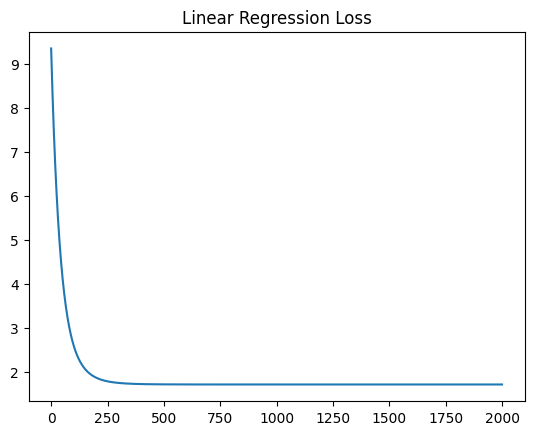

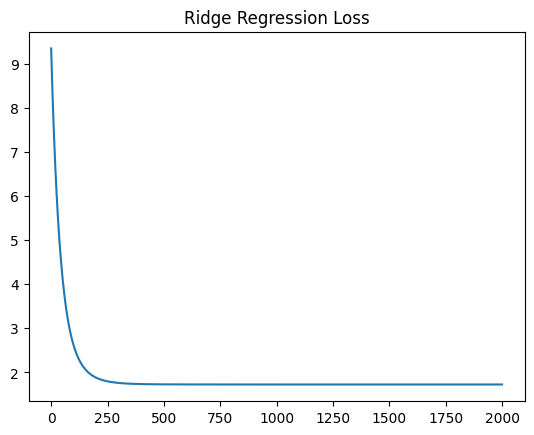

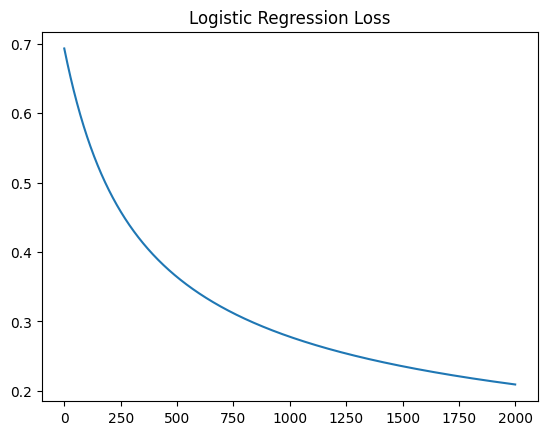

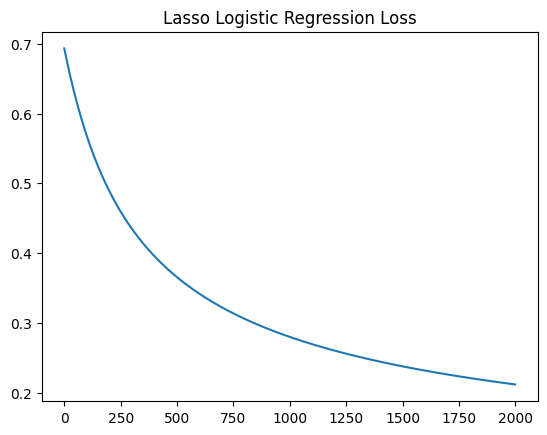

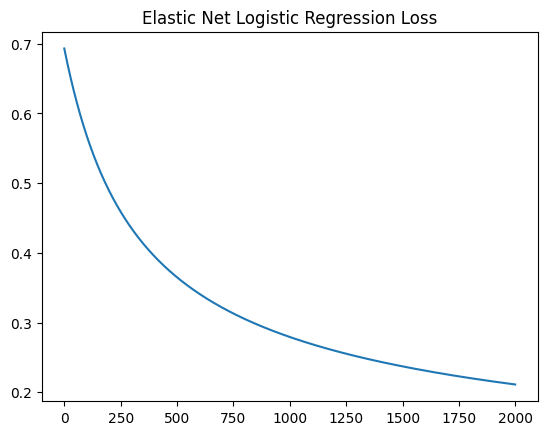

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2027)

# ---- 参数设置 ----
n_samples = 400
n_features = 50

# 输入特征矩阵
X = np.random.normal(0, 1, (n_samples, n_features))

# 连续目标：血压水平（由前 5 个特征决定）
blood_pressure = (
    X[:,0]*1.5 +
    X[:,1]*(-2.0) +
    X[:,2]*0.8 +
    X[:,3]*2.5 +
    X[:,4]*(-1.0) +
    np.random.normal(0, 2, n_samples)
)

# 分类目标：是否糖尿病（由特征 10-15 决定）
logits = (
    X[:,10]*1.2 +
    X[:,11]*(-1.5) +
    X[:,12]*2.0 +
    X[:,13]*(-0.8) +
    X[:,14]*1.5 +
    X[:,15]*(-2.0)
)
prob = 1 / (1 + np.exp(-logits))
diabetes = (prob > 0.5).astype(int)

# 整理目标变量
y_reg = blood_pressure.reshape(-1,1)
y_clf = diabetes.reshape(-1,1)

# 标准化输入特征并加截距
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / (X_std + 1e-8)

X_lin = np.hstack([np.ones((n_samples,1)), X_scaled])  # 线性回归设计矩阵
X_log = np.hstack([np.ones((n_samples,1)), X_scaled])  # 逻辑回归设计矩阵

# ---- 通用训练函数 ----
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_model(X, y, loss_type="linear", lam=0.1, alpha=0.5, lr=0.01, epochs=2000):
    m, n = X.shape
    theta = np.zeros((n,1))
    losses = []
    
    for epoch in range(epochs):
        z = X @ theta
        if loss_type in ["logistic", "lasso", "elasticnet"]:
            y_hat = sigmoid(z)
            error = y_hat - y
        else:
            y_hat = z
            error = y_hat - y
        
        # 损失函数和梯度
        if loss_type == "linear":
            loss = (1/(2*m)) * np.sum(error**2)
            grad = (1/m) * (X.T @ error)
        
        elif loss_type == "ridge":
            loss = (1/(2*m)) * np.sum(error**2) + (lam/(2*m)) * np.sum(theta[1:]**2)
            grad = (1/m) * (X.T @ error)
            grad[1:] += (lam/m) * theta[1:]
        
        elif loss_type == "logistic":
            loss = -(1/m) * np.sum(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8))
            grad = (1/m) * (X.T @ error)
        
        elif loss_type == "lasso":
            loss = -(1/m) * np.sum(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8)) \
                   + (lam/m) * np.sum(np.abs(theta[1:]))
            grad = (1/m) * (X.T @ error)
            grad[1:] += (lam/m) * np.sign(theta[1:])
        
        elif loss_type == "elasticnet":
            loss = -(1/m) * np.sum(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8)) \
                   + alpha*(lam/m)*np.sum(np.abs(theta[1:])) \
                   + (1-alpha)*(lam/(2*m))*np.sum(theta[1:]**2)
            grad = (1/m) * (X.T @ error)
            grad[1:] += alpha*(lam/m)*np.sign(theta[1:]) + (1-alpha)*(lam/m)*theta[1:]
        
        losses.append(loss)
        theta -= lr * grad
    
    return theta, losses

# ---- 练习示例 ----
theta_lin, losses_lin = train_model(X_lin, y_reg, loss_type="linear")
plt.plot(losses_lin); plt.title("Linear Regression Loss"); plt.show()

theta_ridge, losses_ridge = train_model(X_lin, y_reg, loss_type="ridge", lam=0.1)
plt.plot(losses_ridge); plt.title("Ridge Regression Loss"); plt.show()

theta_log, losses_log = train_model(X_log, y_clf, loss_type="logistic")
plt.plot(losses_log); plt.title("Logistic Regression Loss"); plt.show()

theta_lasso, losses_lasso = train_model(X_log, y_clf, loss_type="lasso", lam=0.1)
plt.plot(losses_lasso); plt.title("Lasso Logistic Regression Loss"); plt.show()

theta_en, losses_en = train_model(X_log, y_clf, loss_type="elasticnet", lam=0.1, alpha=0.5)
plt.plot(losses_en); plt.title("Elastic Net Logistic Regression Loss"); plt.show()


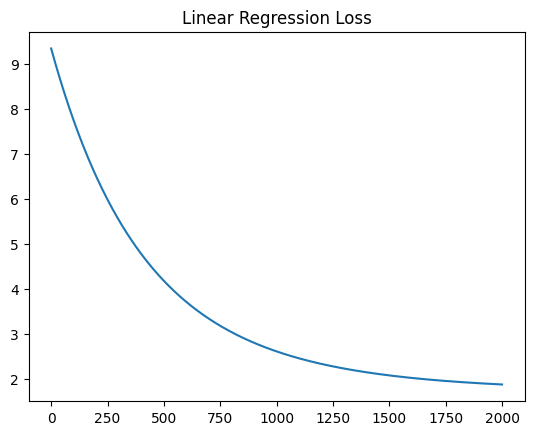

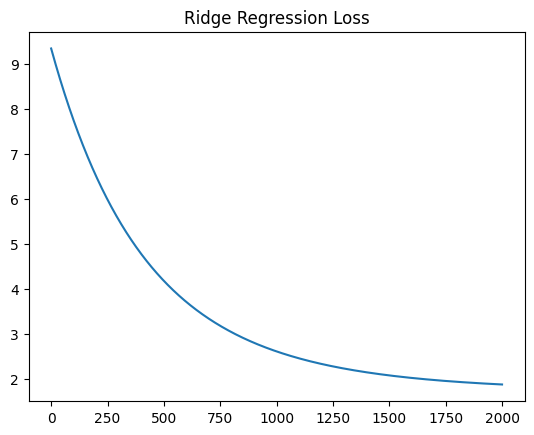

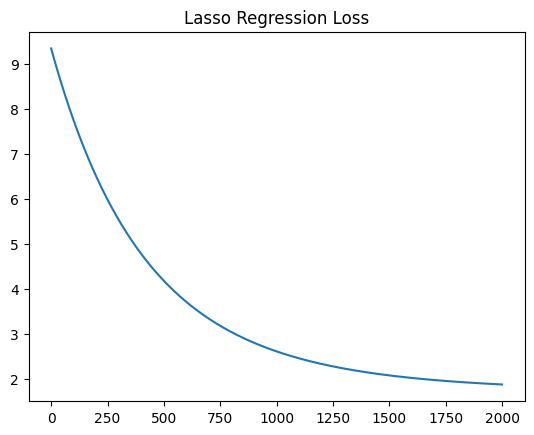

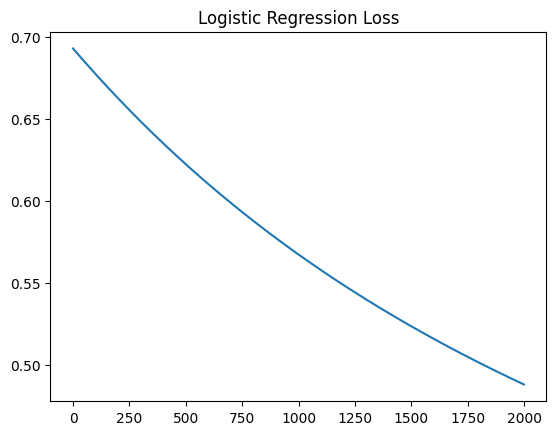

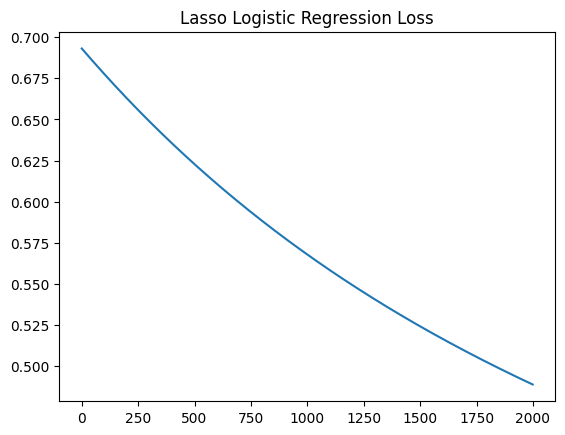

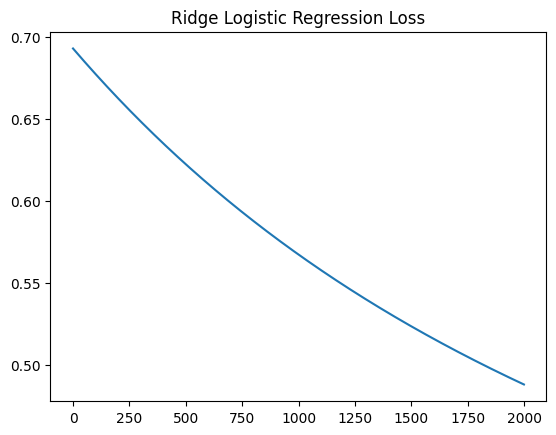

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2027)

# ---- 参数设置 ----
n_samples = 400
n_features = 50

# 输入特征矩阵
X = np.random.normal(0, 1, (n_samples, n_features))

# 连续目标：血压水平（由前 5 个特征决定）
blood_pressure = (
    X[:,0]*1.5 +
    X[:,1]*(-2.0) +
    X[:,2]*0.8 +
    X[:,3]*2.5 +
    X[:,4]*(-1.0) +
    np.random.normal(0, 2, n_samples)
)

# 分类目标：是否糖尿病（由特征 10-15 决定）
logits = (
    X[:,10]*1.2 +
    X[:,11]*(-1.5) +
    X[:,12]*2.0 +
    X[:,13]*(-0.8) +
    X[:,14]*1.5 +
    X[:,15]*(-2.0)
)
prob = 1 / (1 + np.exp(-logits))
diabetes = (prob > 0.5).astype(int)

# 整理目标变量
y_reg = blood_pressure.reshape(-1,1)
y_clf = diabetes.reshape(-1,1)

# 标准化输入特征并加截距
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / (X_std + 1e-8)

X_lin = np.hstack([np.ones((n_samples,1)), X_scaled])  # 线性回归设计矩阵
X_log = np.hstack([np.ones((n_samples,1)), X_scaled])  # 逻辑回归设计矩阵

# ---- 普通线性回归 ---- 
m, n = X_lin.shape 
theta = np.zeros((n,1)) 
lr = 0.001 
epochs = 2000 
losses_lin = [] 
for epoch in range(epochs): 
    y_hat = X_lin @ theta 
    error = y_hat - y_reg 
    loss = (1/(2*m)) * np.sum(error**2) 
    losses_lin.append(loss) 
    grad = (1/m) * (X_lin.T @ error) 
    theta -= lr * grad 
plt.plot(losses_lin); plt.title("Linear Regression Loss"); plt.show()


# ---- 岭回归(正则化L2线性回归) ----
m, n = X_lin.shape 
theta = np.zeros((n,1)) 
lr = 0.001 
epochs = 2000 
lambda_ridge = 0.1
losses_ridge = [] 
for epoch in range(epochs): 
    y_hat = X_lin @ theta 
    error = y_hat - y_reg 
    loss = (1/(2*m)) * np.sum(error**2) + (lambda_ridge/(2*m)) * np.sum(theta[1:]**2)
    losses_ridge.append(loss) 
    grad = (1/m) * (X_lin.T @ error) 
    grad[1:] += (lambda_ridge/m) * theta[1:]
    theta -= lr * grad
plt.plot(losses_ridge); plt.title("Ridge Regression Loss"); plt.show()



# ---- Lasso 回归（正则化L1线性回归） ----
m, n = X_lin.shape 
theta = np.zeros((n,1)) 
lr = 0.001 
epochs = 2000 
lambda_lasso = 0.1
losses_lasso = [] 
for epoch in range(epochs): 
    y_hat = X_lin @ theta 
    error = y_hat - y_reg 
    loss = (1/(2*m)) * np.sum(error**2) + (lambda_lasso/m) * np.sum(np.abs(theta[1:]))
    losses_lasso.append(loss) 
    grad = (1/m) * (X_lin.T @ error) 
    grad[1:] += (lambda_lasso/m) * np.sign(theta[1:])
    theta -= lr * grad
plt.plot(losses_lasso); plt.title("Lasso Regression Loss"); plt.show()

# ---- 逻辑回归 ----
m, n = X_log.shape 
theta = np.zeros((n,1)) 
lr = 0.001 
epochs = 2000
losses_log = [] 
for epoch in range(epochs):
    logits = X_log @ theta 
    y_hat = 1 / (1 + np.exp(-logits)) 
    loss = -(1/m) * np.sum(y_clf * np.log(y_hat + 1e-8) + (1 - y_clf) * np.log(1 - y_hat + 1e-8)) 
    losses_log.append(loss) 
    error = y_hat - y_clf 
    grad = (1/m) * (X_log.T @ error) 
    theta -= lr * grad
plt.plot(losses_log); plt.title("Logistic Regression Loss"); plt.show()

# ---- Lasso 逻辑回归 ----
m, n = X_log.shape 
theta = np.zeros((n,1)) 
lr = 0.001 
epochs = 2000
lambda_lasso = 0.1
losses_lasso_log = [] 
for epoch in range(epochs):
    logits = X_log @ theta 
    y_hat = 1 / (1 + np.exp(-logits)) 
    loss = -(1/m) * np.sum(y_clf * np.log(y_hat + 1e-8) + (1 - y_clf) * np.log(1 - y_hat + 1e-8)) \
           + (lambda_lasso/m) * np.sum(np.abs(theta[1:]))
    losses_lasso_log.append(loss) 
    error = y_hat - y_clf 
    grad = (1/m) * (X_log.T @ error) 
    grad[1:] += (lambda_lasso/m) * np.sign(theta[1:])
    theta -= lr * grad
plt.plot(losses_lasso_log); plt.title("Lasso Logistic Regression Loss"); plt.show()


# ---- Ridge 逻辑回归 ----
m, n = X_log.shape 
theta = np.zeros((n,1)) 
lr = 0.001 
epochs = 2000
lambda_ridge = 0.1
losses_ridge_log = [] 
for epoch in range(epochs):
    logits = X_log @ theta 
    y_hat = 1 / (1 + np.exp(-logits)) 
    loss = -(1/m) * np.sum(y_clf * np.log(y_hat + 1e-8) + (1 - y_clf) * np.log(1 - y_hat + 1e-8)) \
           + (lambda_ridge/(2*m)) * np.sum(theta[1:]**2)
    losses_ridge_log.append(loss) 
    error = y_hat - y_clf 
    grad = (1/m) * (X_log.T @ error) 
    grad[1:] += (lambda_ridge/m) * theta[1:]
    theta -= lr * grad
plt.plot(losses_ridge_log); plt.title("Ridge Logistic Regression Loss"); plt.show() 



# ---- Elastic Net 逻辑回归 ----
m, n = X_log.shape 
theta = np.zeros((n,1))
lr = 0.001 
epochs = 2000   
lambda_en = 0.1
alpha_en = 0.5
losses_en_log = []
for epoch in range(epochs):
    logits = X_log @ theta 
    y_hat = 1 / (1 + np.exp(-logits)) 
    loss = -(1/m) * np.sum(y_clf * np.log(y_hat + 1e-8) + (1 - y_clf) * np.log(1 - y_hat + 1e-8))
    loss += alpha_en*(lambda_en/m)*np.sum(np.abs(theta[1:])) + (1-alpha_en)*(lambda_en/(2*m))*np.sum(theta[1:]**2)
    losses_en_log.append(loss) 
    error = y_hat - y_clf 
    grad = (1/m) * (X_log.T @ error) 
    grad[1:] += alpha_en*(lambda_en/m)*np.sign(theta[1:]) + (1-alpha_en)*(lambda_en/m)*theta[1:]
    theta -= lr * grad
plt.plot(losses_en_log); plt.title("Elastic Net Logistic Regression Loss"); plt.show()


# ---- Elastic Net 线性回归 ----
m, n = X_lin.shape 
theta = np.zeros((n,1)) 
lr = 0.001 
epochs = 2000
lambda_en = 0.1
alpha_en = 0.5
losses_en_lin = [] 
for epoch in range(epochs): 
    y_hat = X_lin @ theta 
    error = y_hat - y_reg 
    loss = (1/(2*m)) * np.sum(error**2) + alpha_en*(lambda_en/m)*np.sum(np.abs(theta[1:])) + (1-alpha_en)*(lambda_en/(2*m))*np.sum(theta[1:]**2)
    losses_en_lin.append(loss) 
    grad = (1/m) * (X_lin.T @ error) 
    grad[1:] += alpha_en*(lambda_en/m)*np.sign(theta[1:]) + (1-alpha_en)*(lambda_en/m)*theta[1:]
    theta -= lr * grad
plt.plot(losses_en_lin); plt.title("Elastic Net Linear Regression Loss"); plt.show()


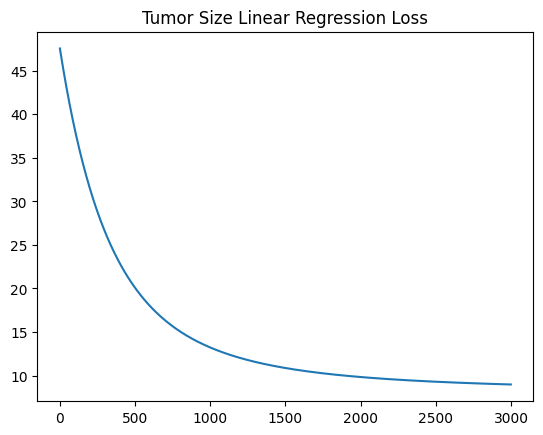

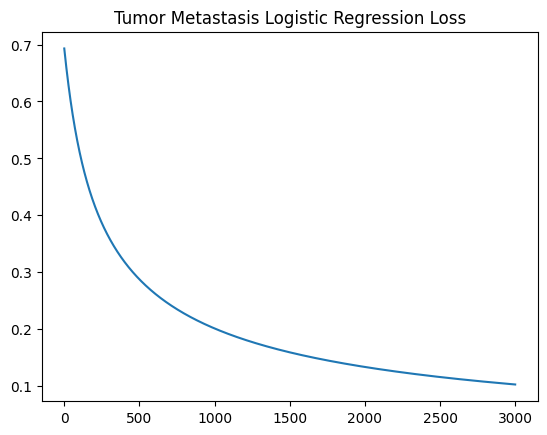

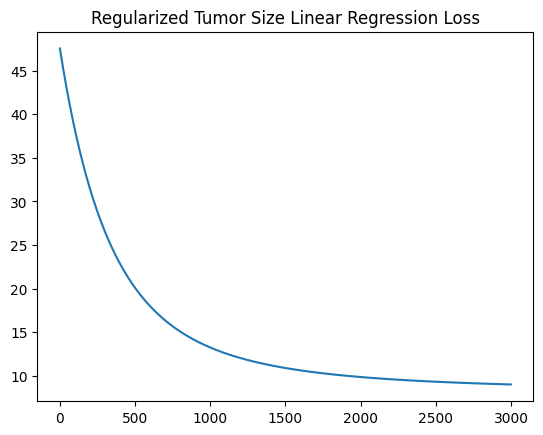

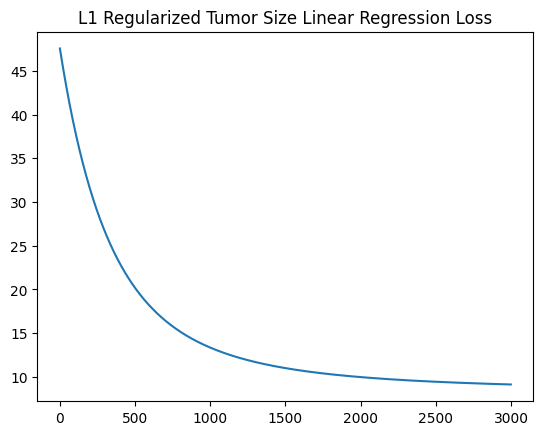

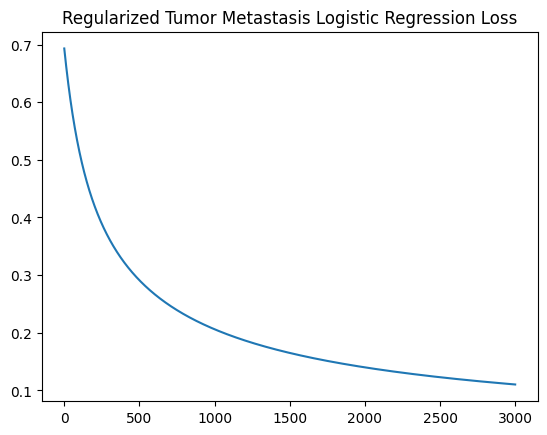

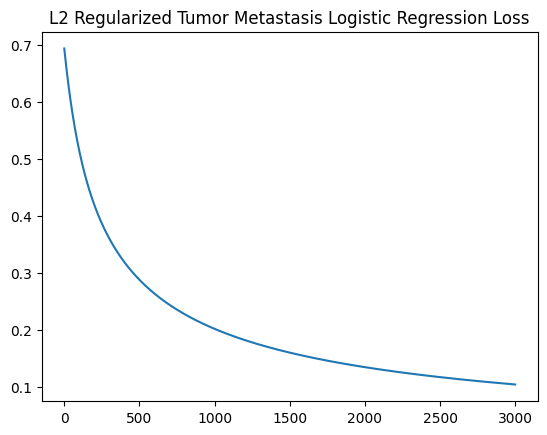

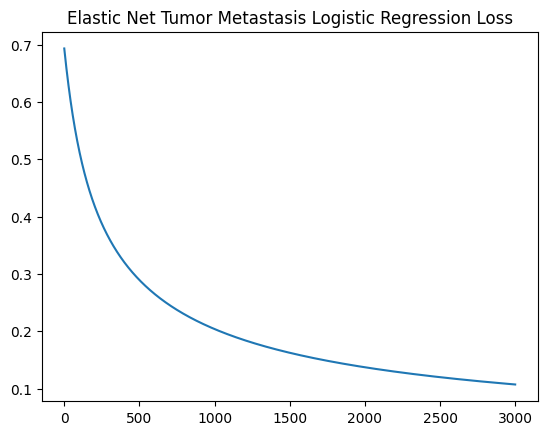

选中的基因索引: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200]
选中的基因: ['Gene_0', 'Gene_1', 'Gene_2', 'Gene_3', 'Gene_4', 'Gene_5', 'Gene_6', 'Gene_7', 'Gene_8', 'Gene_9', 'Gene_10', 'Gene_11', 'Gene_12', 'Gene_13', 'Gene_14', 'Gene_15', 

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 
np.random.seed(2031) 

# ---- 参数设置 ---- 
n_samples = 500 
n_genes = 200 

# 输入特征矩阵 (基因表达) 
X = np.random.normal(0, 1, (n_samples, n_genes)) 

# 连续目标：肿瘤大小（由基因 1-10 增殖模块 + 基因 50-60 代谢模块决定） 
tumor_size = ( X[:,0:10].sum(axis=1)*1.5 + X[:,50:60].sum(axis=1)*2.0 + np.random.normal(0, 5, n_samples) ) 

# 分类目标：肿瘤是否转移（由基因 100-120 EMT模块 + 基因 150-160 免疫模块决定） 
logits = ( X[:,100:120].sum(axis=1)*1.2 + X[:,150:160].sum(axis=1)*(-1.5) ) 
prob = 1 / (1 + np.exp(-logits)) 
tumor_metastasis = (prob > 0.5).astype(int) 

# 整理目标变量 
y_reg = tumor_size.reshape(-1,1) 
y_clf = tumor_metastasis.reshape(-1,1) 

# 标准化输入特征并加截距 
X_mean = X.mean(axis=0) 
X_std = X.std(axis=0) 
X_scaled = (X - X_mean) / (X_std + 1e-8)

X_lin = np.hstack([np.ones((n_samples,1)), X_scaled]) # 线性回归设计矩阵 
X_log = np.hstack([np.ones((n_samples,1)), X_scaled]) # 逻辑回归设计矩阵

# ---- 线性回归 ---- 
m, n = X_lin.shape
theta = np.zeros((n,1))
lr = 0.001
epochs = 3000
losses_lin = []
for epoch in range(epochs):
    y_hat = X_lin @ theta
    error = y_hat - y_reg
    loss = (1/(2*m)) * np.sum(error**2)
    losses_lin.append(loss)
    grad = (1/m) * (X_lin.T @ error)
    theta -= lr * grad

plt.plot(losses_lin); plt.title("Tumor Size Linear Regression Loss"); plt.show()

# ---- 逻辑回归 ----
m, n = X_log.shape
theta = np.zeros((n,1))
lr = 0.01
epochs = 3000
losses_log = []
for epoch in range(epochs):
    logits = X_log @ theta
    y_hat = 1 / (1 + np.exp(-logits))
    loss = -(1/m) * np.sum(y_clf * np.log(y_hat + 1e-8) + (1 - y_clf) * np.log(1 - y_hat + 1e-8))
    losses_log.append(loss)
    error = y_hat - y_clf
    grad = (1/m) * (X_log.T @ error)
    theta -= lr * grad

plt.plot(losses_log); plt.title("Tumor Metastasis Logistic Regression Loss"); plt.show()

# ---- 正则化线性回归(L2) ----
m, n = X_lin.shape
theta = np.zeros((n,1))
lr = 0.001
epochs = 3000
lambda_ridge = 0.1
losses_ridge = []
for epoch in range(epochs):
    y_hat = X_lin @ theta
    error = y_hat - y_reg
    loss = (1/(2*m)) * np.sum(error**2) + (lambda_ridge/(2*m)) * np.sum(theta[1:]**2)
    losses_ridge.append(loss)
    grad = (1/m) * (X_lin.T @ error)
    grad[1:] += (lambda_ridge/m) * theta[1:]
    theta -= lr * grad  
plt.plot(losses_ridge); plt.title("Regularized Tumor Size Linear Regression Loss"); plt.show()



# ---- 正则化线性回归（L1） ----
m, n = X_lin.shape
theta = np.zeros((n,1))
lr = 0.001
epochs = 3000
lambda_lasso = 0.1
losses_lasso_lin = []
for epoch in range(epochs):
    y_hat = X_lin @ theta
    error = y_hat - y_reg
    loss = (1/(2*m)) * np.sum(error**2) + (lambda_lasso/m) * np.sum(np.abs(theta[1:]))
    losses_lasso_lin.append(loss)
    grad = (1/m) * (X_lin.T @ error)
    grad[1:] += (lambda_lasso/m) * np.sign(theta[1:])
    theta -= lr * grad  
plt.plot(losses_lasso_lin); plt.title("L1 Regularized Tumor Size Linear Regression Loss"); plt.show()


# ---- 正则化逻辑回归(L1) ----
m, n = X_log.shape
theta = np.zeros((n,1))
lr = 0.01
epochs = 3000
lambda_lasso = 0.1
losses_lasso = []
for epoch in range(epochs):
    logits = X_log @ theta
    y_hat = 1 / (1 + np.exp(-logits))
    loss = -(1/m) * np.sum(y_clf * np.log(y_hat + 1e-8) + (1 - y_clf) * np.log(1 - y_hat + 1e-8)) \
           + (lambda_lasso/m) * np.sum(np.abs(theta[1:]))
    losses_lasso.append(loss)
    error = y_hat - y_clf
    grad = (1/m) * (X_log.T @ error)
    grad[1:] += (lambda_lasso/m) * np.sign(theta[1:])
    theta -= lr * grad
plt.plot(losses_lasso); plt.title("Regularized Tumor Metastasis Logistic Regression Loss"); plt.show()


# ---- 正则化逻辑回归(L2) ----
m, n = X_log.shape
theta = np.zeros((n,1))
lr = 0.01
epochs = 3000
lambda_ridge = 0.1
losses_ridge_log = []
for epoch in range(epochs):
    logits = X_log @ theta
    y_hat = 1 / (1 + np.exp(-logits))
    loss = -(1/m) * np.sum(y_clf * np.log(y_hat + 1e-8) + (1 - y_clf) * np.log(1 - y_hat + 1e-8)) \
           + (lambda_ridge/(2*m)) * np.sum(theta[1:]**2)
    losses_ridge_log.append(loss)
    error = y_hat - y_clf
    grad = (1/m) * (X_log.T @ error)
    grad[1:] += (lambda_ridge/m) * theta[1:]
    theta -= lr * grad
plt.plot(losses_ridge_log); plt.title("L2 Regularized Tumor Metastasis Logistic Regression Loss"); plt.show()


# ---- Elastic Net 逻辑回归 ----
m, n = X_log.shape
theta = np.zeros((n,1))
lr = 0.01
epochs = 3000   
lambda_en = 0.1
alpha_en = 0.5
losses_en_log = []
for epoch in range(epochs): 
    logits = X_log @ theta 
    y_hat = 1 / (1 + np.exp(-logits)) 
    loss = -(1/m) * np.sum(y_clf * np.log(y_hat + 1e-8) + (1 - y_clf) * np.log(1 - y_hat + 1e-8))
    loss += alpha_en*(lambda_en/m)*np.sum(np.abs(theta[1:])) + (1-alpha_en)*(lambda_en/(2*m))*np.sum(theta[1:]**2)
    losses_en_log.append(loss) 
    error = y_hat - y_clf 
    grad = (1/m) * (X_log.T @ error) 
    grad[1:] += alpha_en*(lambda_en/m)*np.sign(theta[1:]) + (1-alpha_en)*(lambda_en/m)*theta[1:]
    theta -= lr * grad
plt.plot(losses_en_log); plt.title("Elastic Net Tumor Metastasis Logistic Regression Loss"); plt.show()


# 假设训练完成后得到的参数是 theta
theta_lasso = theta.flatten()

# 选择非零基因
selected_idx = np.where(theta_lasso != 0)[0]

# 如果有基因名字列表
gene_names = [f"Gene_{i}" for i in range(n_genes+1)]  # +1 因为有截距
selected_genes = [gene_names[i] for i in selected_idx]

print("选中的基因索引:", selected_idx)
print("选中的基因:", selected_genes)



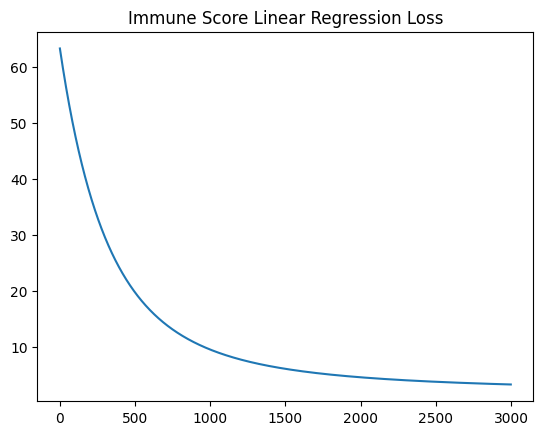

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 
np.random.seed(2035) 

# ---- 参数设置 ---- 
n_samples = 400 
n_genes = 250 

# 输入特征矩阵 (基因表达) 
X = np.random.normal(0, 1, (n_samples, n_genes)) 

# 连续目标：免疫评分（免疫激活 + 免疫抑制） 

immune_score = ( X[:,0:20].sum(axis=1)*2.0 +             # 激活模块 
                X[:,50:70].sum(axis=1)*(-1.5) +          # 抑制模块 
                np.random.normal(0, 3, n_samples) ) 


# 分类目标：免疫治疗反应（EMT + 代谢模块） 

logits = ( X[:,150:170].sum(axis=1)*(-1.2) +            # EMT 模块（负相关） 
          X[:,100:120].sum(axis=1)*1.8                  # 代谢模块（正相关） 
        ) 

prob = 1 / (1 + np.exp(-logits)) 
response = (prob > 0.5).astype(int) 
        
        
# 整理目标变量 
y_reg = immune_score.reshape(-1,1) 
y_clf = response.reshape(-1,1) 

# 标准化输入特征并加截距 
X_mean = X.mean(axis=0) 
X_std = X.std(axis=0) 
X_scaled = (X - X_mean) / (X_std + 1e-8) 
X_lin = np.hstack([np.ones((n_samples,1)), X_scaled]) # 线性回归设计矩阵 
X_log = np.hstack([np.ones((n_samples,1)), X_scaled]) # 逻辑回归设计矩阵


# ----- 普通线性回归 -------
m , n = X_lin.shape
theta = np.zeros((n,1))
lr = 0.001
epochs = 3000
losses_lin = []
for epoch in range(epochs):
    y_hat = X_lin @ theta
    error = y_hat - y_reg
    loss = (1/(2*m)) * np.sum(error**2)
    losses_lin.append(loss)
    grad = (1/m) * (X_lin.T @ error)
    theta -= lr * grad

plt.plot(losses_lin); plt.title("Immune Score Linear Regression Loss"); plt.show()  


# ----- 普通逻辑回归 -------
m , n = X_log.shape
theta = np.zeros((n,1))
lr = 0.01
epochs = 3000
losses_log = []
for epoch in range(epochs):
    logits = X_log @ theta
    y_hat = 1 / (1 + np.exp(-logits))
    loss = -(1/m) * np.sum(y_clf * np.log(y_hat + 1e-8) + (1 - y_clf) * np.log(1 - y_hat + 1e-8))
    losses_log.append(loss)
    error = y_hat - y_clf
    grad = (1/m) * (X_log.T @ error)
    theta -= lr * grad

plt.plot(losses_log); plt.title("Immune Therapy Response Logistic Regression Loss"); plt.show()


